# WP1 Stage 04: band structures

Read-only post-processing of five completed ZnIn2S4 phases. This notebook calls shared scripts, validates raw results against accepted analysis, and exports 5 standalone single-panel figures. No calculation is launched; calculation files and accepted results are never rewritten.

Use the repository's isolated `.venv-wp1-plots` environment with NumPy, Matplotlib, pymatgen, nbformat, nbclient and ipykernel, plus an editable installation of the local CMW checkout (`python -m pip install -e /path/to/computational-modelling-workflow`, performed outside this notebook). The actual interpreter, packages, CMW module path and commit are recorded below.

Rerun with `execute_wp1_plot_notebook.py` from the repository root or this notebook's directory. Each execution uses a fresh kernel and one numerical thread. Each line segment uses the actual calculation-cell reciprocal metric including 2π. Repeated endpoints are retained and disconnected branches have separate ticks around display-only gaps, never connecting band lines.

## Editable configuration

Set `ROOT_OVERRIDE` only if executing outside the repository. The default (-4, 4) eV window focuses on band edges and is checked against calculated coverage. Set (-8, 4) for a wider diagnostic rerun, without an additional default figure set. Set `X_AXIS_TITLE` to `"Wave vector"` only if desired. `OVERWRITE=True` replaces only this workflow's exact phase/kind filenames; unrelated files are untouched. One requested format produces one file, with PNG at 600 dpi only when explicitly selected. No CSV or cache export is enabled.

In [1]:
from pathlib import Path
import os
import sys

ROOT_OVERRIDE = None
PHASE_SELECTION = ["spinel", "alpha1", "beta", "IIa_prime", "IIb"]
REFERENCE = "vbm"  # audited dense uniform-mesh eigenvalue VBM, also available to DOS/PDOS
ENERGY_LIMITS = (-4.0, 4.0)
X_AXIS_TITLE = ""  # optional: "Wave vector"
BRANCH_GAP = None  # family defaults: cF2 .0225, hR1 .0375, hP2 .055 of physical span
OUTPUT_FORMAT = "pdf"  # one of pdf, svg, png
OUTPUT_DIRECTORY = None  # default: this results directory / figures
OVERWRITE = True

# Task-local setup, before importing numerical/plotting libraries.
for name in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS", "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[name] = "1"
os.environ["PYTHONDONTWRITEBYTECODE"] = "1"
os.environ["MPLBACKEND"] = "Agg"
wp1_relative = Path("vasp/wp1_polymorph_polytype_benchmark")
candidates = [Path(ROOT_OVERRIDE).expanduser().resolve()] if ROOT_OVERRIDE else [Path.cwd().resolve(), *Path.cwd().resolve().parents]
root = next((p for p in candidates if (p / wp1_relative / "structure/RAW_STRUCTURE_PROVENANCE.md").is_file()), None)
if root is None:
    raise RuntimeError("Run inside the repository or set ROOT_OVERRIDE explicitly")
sys.path.insert(0, str(root / wp1_relative / "script/wp1"))

## Environment and resolved scientific sources

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from wp1_electronic_plot_data import load_all, source_mapping, energy_window, accepted
from wp1_electronic_plot_style import RC, default_output, environment_summary, save_figure, display_figure
from plot_wp1_bands import plot_bands

environment = environment_summary()
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame(environment.items(), columns=["component", "actual version/location"]))
sources = source_mapping(root, PHASE_SELECTION)
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame([{"phase": phase, "branch": branch, "source": str(path.relative_to(root))}
                          for phase, branches in sources.items() for branch, path in branches.items()]))

,component,actual version/location
0,Python,3.14.6
1,executable,/Users/liangze/Desktop/Imperial/Year 26-27/fyp/computational/.venv-wp1-plots/bin/python
2,numpy,2.5.3
3,matplotlib,3.11.1
4,pymatgen,2026.5.4
5,spglib,2.7.0
6,nbformat,5.11.1
7,nbclient,0.11.0
8,ipykernel,7.3.0
9,CMW module,/Users/liangze/Desktop/squiddy tools/computational-modelling-workflow/src/cmw/analysis/electronic.py


,phase,branch,source
0,spinel,dos,vasp/wp1_polymorph_polytype_benchmark/calculation/04_electronic_structure/01_dos_pdos/spinel
1,spinel,band,vasp/wp1_polymorph_polytype_benchmark/calculation/04_electronic_structure/02_band/spinel
2,spinel,parent,vasp/wp1_polymorph_polytype_benchmark/calculation/03_static_scf/spinel
3,alpha1,dos,vasp/wp1_polymorph_polytype_benchmark/calculation/04_electronic_structure/01_dos_pdos/alpha1
4,alpha1,band,vasp/wp1_polymorph_polytype_benchmark/calculation/04_electronic_structure/02_band/alpha1
5,alpha1,parent,vasp/wp1_polymorph_polytype_benchmark/calculation/03_static_scf/alpha1
6,beta,dos,vasp/wp1_polymorph_polytype_benchmark/calculation/04_electronic_structure/01_dos_pdos/beta
7,beta,band,vasp/wp1_polymorph_polytype_benchmark/calculation/04_electronic_structure/02_band/beta
8,beta,parent,vasp/wp1_polymorph_polytype_benchmark/calculation/03_static_scf/beta
9,IIa_prime,dos,vasp/wp1_polymorph_polytype_benchmark/calculation/04_electronic_structure/01_dos_pdos/IIa_prime


## Validation and common energy reference

All ten Stage 04 branches must be completed fixed-density, nonmagnetic PBE outputs with the accepted cell, species order, dimensions and gaps. A material discrepancy raises an error before export. The exact reference source is retained for each phase. Parsing is sequential, and only required XML spectra/metadata are requested.

The authoritative zero is each phase's audited **dense uniform-mesh sampled VBM**, checked against `electronic_structure_summary.csv` and obtained from the DOS branch's `EIGENVAL`. The selected-PDOS notebook now defaults to exactly this same scalar. Neither the Line-mode Fermi energy nor the plotted path's own maximum sets this zero. Small positive path-VBM excursions are retained as legitimate finite-sampling differences, not clipped or re-zeroed.

In [3]:
data = load_all(root, PHASE_SELECTION, REFERENCE)
window = energy_window(data, "band", ENERGY_LIMITS)
output_directory = Path(OUTPUT_DIRECTORY).expanduser().resolve() if OUTPUT_DIRECTORY else default_output(root)
validation_columns = ["phase", "formula_units", "reference_mode", "reference_eV", "dos_kpoints", "band_kpoints", "bands", "primitive_cells", "uniform_gap_eV", "path_gap_eV", "validation"]
display(pd.DataFrame([d.summary for d in data])[validation_columns])
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame([{"phase": d.summary["phase"], "reference_source": d.summary["reference_source"], "classification": d.summary["classification"]} for d in data]))
display(pd.DataFrame([{"phase": d.summary["phase"], "DOS coverage (eV)": d.dos_coverage, "band coverage (eV)": d.band_coverage} for d in data]))
print(f"Shared energy window: {window} eV; output: {OUTPUT_FORMAT}")
path_extrema = []
for phase in data:
    edges = accepted.band_edges(accepted.parse_eigenval(phase.sources["band"] / "EIGENVAL"))
    path_extrema.append({"phase": phase.summary["phase"], "audited dense VBM (eV)": phase.reference_ev,
                         "path VBM minus reference (eV)": edges["vbm"] - phase.reference_ev,
                         "path gap (eV)": edges["fundamental_gap"],
                         "uniform gap (eV)": phase.summary["uniform_gap_eV"]})
display(pd.DataFrame(path_extrema))

,phase,formula_units,reference_mode,reference_eV,dos_kpoints,band_kpoints,bands,primitive_cells,uniform_gap_eV,path_gap_eV,validation
0,Spinel,8,vbm,4.179865,20,240,304,4,1.317947,1.314507,PASS
1,α₁,3,vbm,4.510352,202,280,112,3,0.304198,0.304197,PASS
2,β,1,vbm,4.533285,202,360,40,1,0.303118,0.303118,PASS
3,IIa′,2,vbm,4.163139,202,360,80,1,0.303574,0.298994,PASS
4,IIb,2,vbm,4.504881,148,360,80,1,0.278638,0.278638,PASS


,phase,reference_source,classification
0,Spinel,vasp/wp1_polymorph_polytype_benchmark/calculation/04_electronic_structure/01_dos_pdos/spinel/EIGENVAL,INDIRECT ON THE SAMPLED UNIFORM MESH
1,α₁,vasp/wp1_polymorph_polytype_benchmark/calculation/04_electronic_structure/01_dos_pdos/alpha1/EIGENVAL,DIRECT ON THE SAMPLED UNIFORM MESH
2,β,vasp/wp1_polymorph_polytype_benchmark/calculation/04_electronic_structure/01_dos_pdos/beta/EIGENVAL,AMBIGUOUS / NEAR-DEGENERATE
3,IIa′,vasp/wp1_polymorph_polytype_benchmark/calculation/04_electronic_structure/01_dos_pdos/IIa_prime/EIGENVAL,INDIRECT ON THE SAMPLED UNIFORM MESH
4,IIb,vasp/wp1_polymorph_polytype_benchmark/calculation/04_electronic_structure/01_dos_pdos/IIb/EIGENVAL,DIRECT ON THE SAMPLED UNIFORM MESH


,phase,DOS coverage (eV),band coverage (eV)
0,Spinel,"(-14.088546000000001, 6.6628549999999995)","(-14.088546000000001, 6.665667)"
1,α₁,"(-15.496621999999999, 4.5435229999999995)","(-15.496621999999999, 4.530747000000001)"
2,β,"(-15.45627, 5.128476999999999)","(-15.45627, 5.128476999999999)"
3,IIa′,"(-15.362354, 5.736045)","(-15.362354, 5.735516)"
4,IIb,"(-15.506012000000002, 5.096025999999999)","(-15.506012000000002, 5.096025999999999)"


Shared energy window: (-4.0, 4.0) eV; output: pdf


,phase,audited dense VBM (eV),path VBM minus reference (eV),path gap (eV),uniform gap (eV)
0,Spinel,4.179865,0.003440,1.314507,1.317947
1,α₁,4.510352,0.000001,0.304197,0.304198
2,β,4.533285,0.000000,0.303118,0.303118
3,IIa′,4.163139,0.004580,0.298994,0.303574
4,IIb,4.504881,0.000000,0.278638,0.278638


## Standalone figures

The common 7 × 5 inch canvas, 1.1 pt bands and -4 to +4 eV VBM-referenced window are unchanged. Normal x tick labels are hidden; explicit 12.5 pt bold Arial Narrow labels are horizontally centered at their tick positions on one shared baseline (axes y = -0.04), with no vertical staggering. The narrower face keeps genuine short c-direction segments readable without stretching them. Each disconnected break adds a fraction of the total physical path span before gaps: cF2/spinel 2.25%, hR1/alpha1 3.75%, and hP2/beta/IIa′/IIb 5.5%. Connected short segments are not expanded. Figures contain no phase labels, captions, gap annotations or default x-axis title. Each PDF is saved, displayed and closed sequentially.

findfont: Failed to find font weight bold, now using 400.


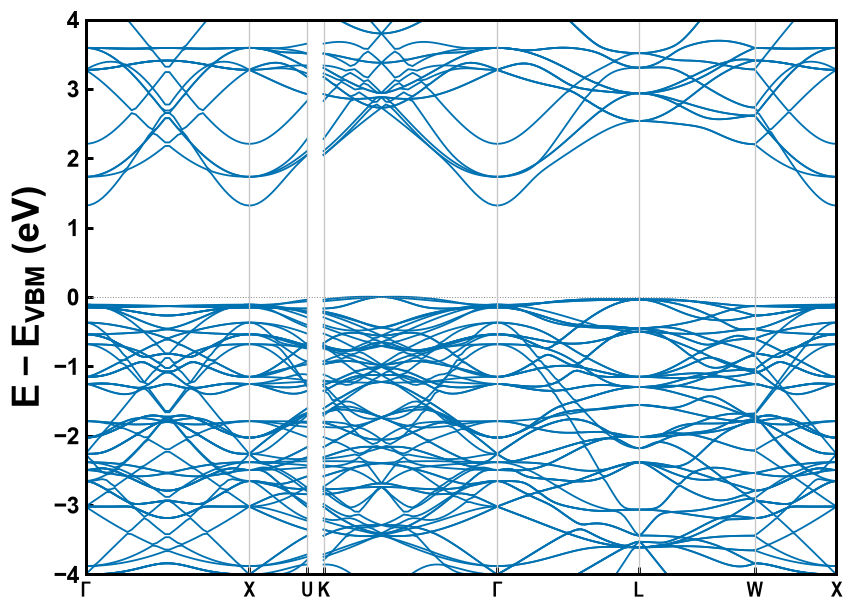

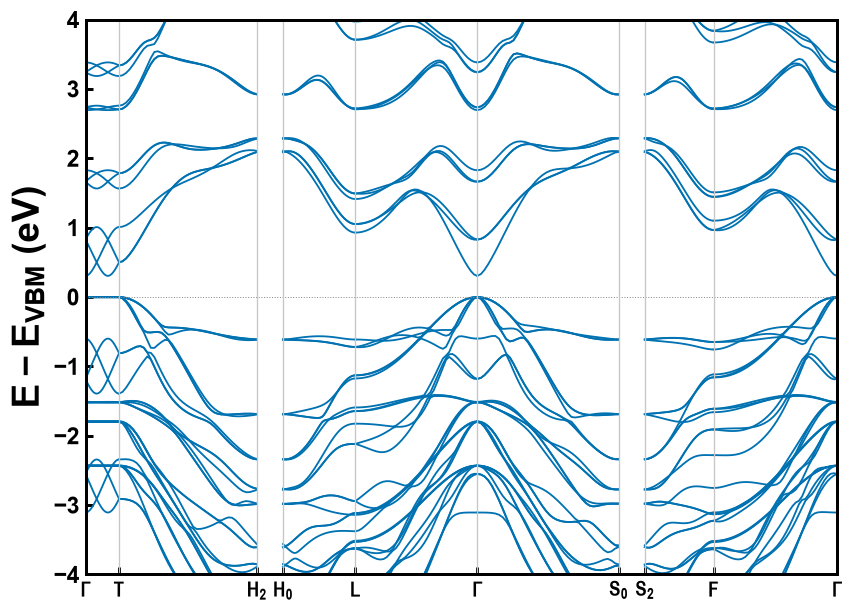

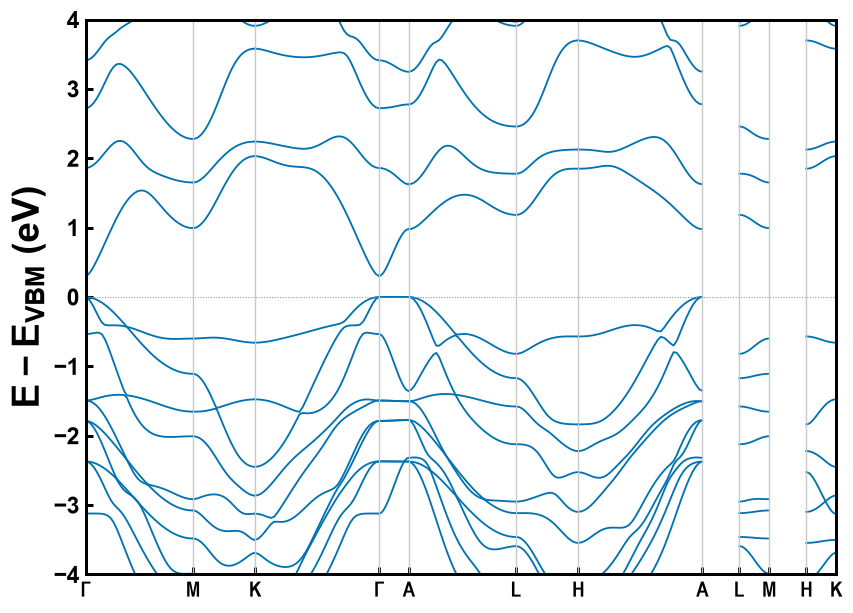

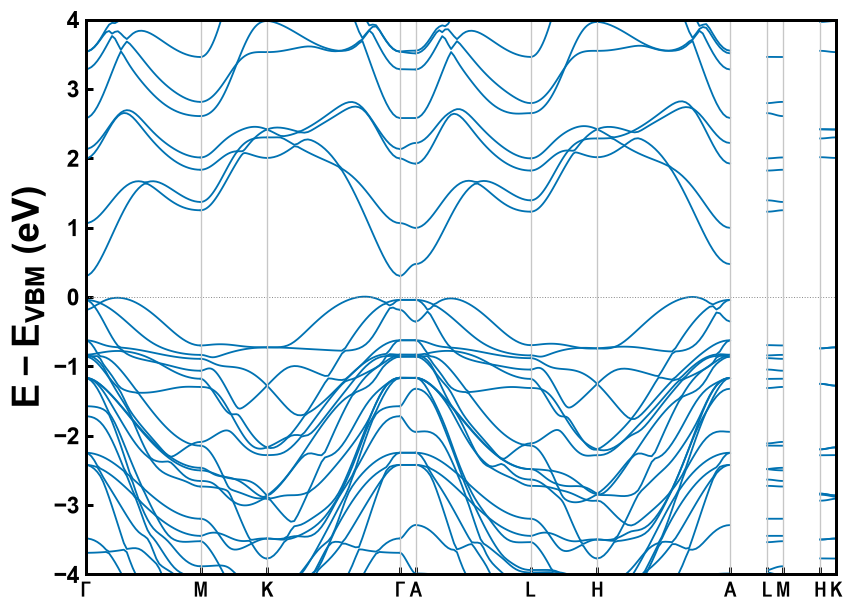

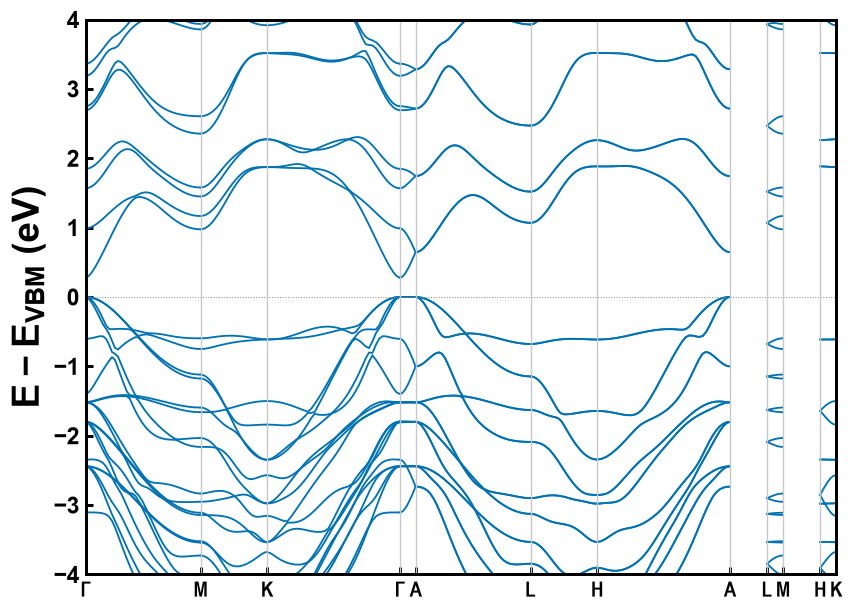

In [4]:
inventory = []
caption_notes = []
for phase in data:
    fig, ax, metadata = plot_bands(phase, window=window, x_title=X_AXIS_TITLE, branch_gap=BRANCH_GAP)
    try:
        path = save_figure(fig, output_directory, phase.phase, "band_structure", output_format=OUTPUT_FORMAT, overwrite=OVERWRITE)
        with mpl.rc_context(RC):
            display_figure(fig)
        caption_notes.append({"phase": phase.summary["phase"], "caption-ready qualification": metadata["caption"]})
        inventory.append({"phase": phase.summary["phase"], "figure": path.name, "axes": len(fig.axes), "plotted bands": len(metadata["band_indices"]), "bytes": path.stat().st_size})
    finally:
        plt.close(fig)

## Interpretation and caption qualifications

These are **PBE electronic structures on PBE+D3(BJ)-relaxed geometries**, evaluated at fixed density (ICHARG=11). No HSE/scissor correction, smoothing, interpolation of extrema or optical-transition inference is applied.

The energy gauge is phase-local: $E-E_{\mathrm{VBM}}$ uses the audited dense uniform-mesh sampled VBM, not the path-only VBM. Consequently, spinel and IIa′ may show small positive valence excursions above zero; the numeric differences are reported above and remain in the plotted arrays. The same scalar is available through the shared DOS/PDOS VBM mode. This is not vacuum alignment or an absolute cross-phase band-offset comparison.

Path-sampled and uniform-mesh gaps remain distinct finite-sampling results, neither a continuous-Brillouin-zone guarantee. **Beta remains ambiguous / near-degenerate direct–indirect** (approximately 1.38 meV splitting in the accepted uniform-mesh analysis); it is not relabelled direct or indirect.

**Spinel and α₁ retain their calculated folded-cell representations**, containing four and three primitive cells, respectively. No bands are removed as duplicates and no unfolding is attempted. Primitive-BZ direct/indirect character must not be inferred solely from these folded plots. Caption-ready qualifications are provided below, outside the figures.

The actual frozen-cell reciprocal metric includes $2\pi$. Every 40-sample segment retains its relative length and ordered repeated endpoints. Disconnected branches are never joined. A copied display-coordinate array adds a constant offset to each continuous branch, inserting the configured path-family graphical gap at each restart, measured from the original physical span rather than the gap-expanded display width. These gaps are NOT additional physical reciprocal-space distances: slopes/effective masses and all scientific analysis must use the unchanged underlying path distances, never display coordinates. The shared -4 to +4 eV window is inside all five phases' computed coverage; wider diagnostics remain configurable.

Execution environment note: macOS marked the editable CMW registration file hidden, which Python skips. This refinement was executed with a process-local `PYTHONPATH` pointing to the existing CMW checkout's `src` directory. For the same setup, launch the runner with `PYTHONPATH="/path/to/computational-modelling-workflow/src"`; no source copying, package replacement or fallback implementation is used. The actual imported module path and commit are recorded above.

Authoritative local evidence: [accepted report](ELECTRONIC_STRUCTURE_ANALYSIS.md), [uniform/path summary](electronic_structure_summary.csv), [audited edges](band_edges.csv) and [path justification](KPOINTS_SELECTION_JUSTIFICATION.md). Structures are checked against Stage 03; fixed-density charge lineage relies on the accepted audit without rereading large restart files. No raw calculation files or accepted conclusions are modified.

Primary references: [VASP band workflow](https://vasp.at/wiki/Band-structure_calculation_using_DFT), [VASP EFERMI](https://vasp.at/wiki/EFERMI) and [SeeK-path original-cell conventions](https://seekpath.readthedocs.io/en/latest/maindoc.html). Local calculated data, not regenerated reference paths, determine these figures.

## Output inventory

No raw arrays, CSV exports, JSON/YAML sidecars or raster preview collection are written by this notebook. Inline images are notebook displays, not a second external figure set.

In [5]:
display(pd.DataFrame(inventory))
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame(caption_notes))
assert len(inventory) == len(PHASE_SELECTION) * 1
assert all(item["axes"] == 1 and item["bytes"] > 1000 for item in inventory)
assert not plt.get_fignums()
print(f"{len(inventory)} standalone {OUTPUT_FORMAT.upper()} figures; all validation gates passed.")

,phase,figure,axes,plotted bands,bytes
0,Spinel,spinel_pbe_band_structure.pdf,1,100,120645
1,α₁,alpha1_pbe_band_structure.pdf,1,43,96672
2,β,beta_pbe_band_structure.pdf,1,15,59103
3,IIa′,IIa_prime_pbe_band_structure.pdf,1,29,91378
4,IIb,IIb_pbe_band_structure.pdf,1,29,87643


,phase,caption-ready qualification
0,Spinel,Calculated folded-cell representation (4 primitive cells); primitive-BZ direct/indirect character cannot be inferred solely from this plot.
1,α₁,Calculated folded-cell representation (3 primitive cells); primitive-BZ direct/indirect character cannot be inferred solely from this plot.
2,β,Calculated-cell band representation.
3,IIa′,Calculated-cell band representation.
4,IIb,Calculated-cell band representation.


5 standalone PDF figures; all validation gates passed.
